In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [11]:

data = pd.read_csv(r"C:\New folder\road_accident.csv")
print("Dataset Loaded Successfully ✅")
data.head()

Dataset Loaded Successfully ✅


,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [17]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   3000 non-null   object
 1   City Name                    3000 non-null   object
 2   Year                         3000 non-null   int64 
 3   Month                        3000 non-null   object
 4   Day of Week                  3000 non-null   object
 5   Time of Day                  3000 non-null   object
 6   Accident Severity            3000 non-null   object
 7   Number of Vehicles Involved  3000 non-null   int64 
 8   Vehicle Type Involved        3000 non-null   object
 9   Number of Casualties         3000 non-null   int64 
 10  Number of Fatalities         3000 non-null   int64 
 11  Weather Conditions           3000 non-null   object
 12  Road Type                    3000 non-null   object
 13  Road Condition               3000

,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,2020.530000,2.996000,5.066000,2.455333,74.940667,44.17700
std,1.683858,1.428285,3.214097,1.717650,26.765088,15.40286
min,2018.000000,1.000000,0.000000,0.000000,30.000000,18.00000
25%,2019.000000,2.000000,2.000000,1.000000,51.000000,31.00000
50%,2021.000000,3.000000,5.000000,2.000000,75.000000,45.00000
75%,2022.000000,4.000000,8.000000,4.000000,99.000000,57.00000
max,2023.000000,5.000000,10.000000,5.000000,120.000000,70.00000


In [18]:
data.isnull().sum()

State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64

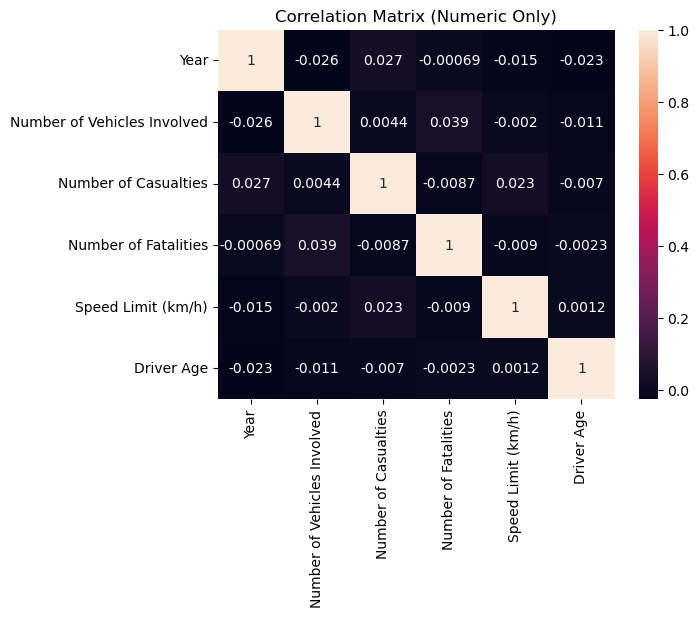

In [20]:
plt.figure()

numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_data.corr(), annot=True)

plt.title("Correlation Matrix (Numeric Only)")
plt.show()

In [22]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("Features:", X.columns)
print("Target:", y.name)

Features: Index(['State Name', 'City Name', 'Year', 'Month', 'Day of Week',
       'Time of Day', 'Accident Severity', 'Number of Vehicles Involved',
       'Vehicle Type Involved', 'Number of Casualties', 'Number of Fatalities',
       'Weather Conditions', 'Road Type', 'Road Condition',
       'Lighting Conditions', 'Traffic Control Presence', 'Speed Limit (km/h)',
       'Driver Age', 'Driver Gender', 'Driver License Status',
       'Alcohol Involvement'],
      dtype='object')
Target: Accident Location Details


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:

data = pd.get_dummies(data, drop_first=True)

print("Categorical columns encoded ✅")
print(data.head())

Categorical columns encoded ✅
   Year  Number of Vehicles Involved  Number of Casualties  \
0  2021                            5                     0   
1  2018                            5                     5   
2  2023                            5                     6   
3  2020                            3                    10   
4  2021                            5                     7   

   Number of Fatalities  Speed Limit (km/h)  Driver Age  \
0                     4                  61          66   
1                     4                  92          60   
2                     5                 120          26   
3                     5                  76          34   
4                     1                 115          30   

   State Name_Arunachal Pradesh  State Name_Assam  State Name_Bihar  \
0                         False             False             False   
1                         False             False             False   
2                         Fal

In [14]:
data = pd.get_dummies(data, drop_first=True)

print("Categorical columns encoded successfully")
data.head()

Categorical columns encoded successfully


,Year,Number of Vehicles Involved,Number of Casualties,Number of Fatalities,Speed Limit (km/h),Driver Age,State Name_Arunachal Pradesh,State Name_Assam,State Name_Bihar,State Name_Chandigarh,...,Lighting Conditions_Daylight,Lighting Conditions_Dusk,Traffic Control Presence_Signals,Traffic Control Presence_Signs,Driver Gender_Male,Driver License Status_Valid,Alcohol Involvement_Yes,Accident Location Details_Curve,Accident Location Details_Intersection,Accident Location Details_Straight Road
0,2021,5,0,4,61,66,False,False,False,False,...,False,False,False,True,True,False,True,True,False,False
1,2018,5,5,4,92,60,False,False,False,False,...,False,True,False,True,True,False,True,False,False,True
2,2023,5,6,5,120,26,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,2020,3,10,5,76,34,False,False,False,False,...,False,False,True,False,False,True,True,False,False,True
4,2021,5,7,1,115,30,False,False,False,False,...,False,True,False,True,True,False,False,False,True,False


In [24]:
data = pd.get_dummies(data, drop_first=True)

In [25]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [27]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [28]:
y_pred = model.predict(X_test)


In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7355555555555555


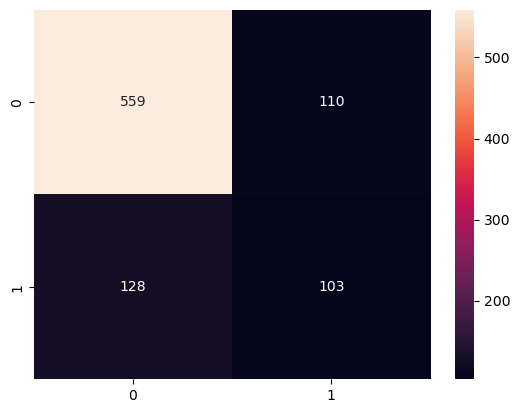

In [30]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()


In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.81      0.84      0.82       669
        True       0.48      0.45      0.46       231

    accuracy                           0.74       900
   macro avg       0.65      0.64      0.64       900
weighted avg       0.73      0.74      0.73       900

